In [ ]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [3]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

## Load participant data and meta files 

In [3]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [4]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

## Load model data and meta files

In [6]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [7]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [8]:
manifest_df  = pd.DataFrame(manifest.values())
# manifest_df

In [10]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment/").glob("*/*room*.pkl"))

output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment_v02/").glob("*/*.pkl"))
# output_paths.extend(list(Path(f"binaural_eval/simulate_2024_human_array_experiment_white_noise_dist/").glob("*/*.pkl")))
# output_paths.append(list(Path(f"binaural_eval/texture_srm_experiment/").glob("*/*.pkl")))

stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

## Get anechoic room for comparison 
# output_paths += list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*eval*room0000.pkl"))
# anech_stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')
 
word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not 'v09' in str(path):
        continue
    if 'arch_search' in str(path):
        continue
    # if not ("word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout" in str(path)) or not ('_arch_' in str(path)):
    #     continue
    if not any(name in str(path) for name in ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    # if not 'mitb46' in path.stem:
    #     continue 
    if 'white_noise' in path.as_posix():
        continue
    if 'texture' in path.as_posix():
        continue

    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    if 'white_noise' in path.as_posix():
        df['distractor_type'] = 'white_noise'
    elif 'texture' in path.as_posix():
        df['distractor_type'] = 'texture'
    else:
        df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [11]:
results.room_type.unique()

array(['speech_distractor_min_reverb', 'speech_distractor_eval',
       'speech_distractor_mitb46'], dtype=object)

In [12]:
results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [13]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [14]:
results.model.unique()

array(['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout'],
      dtype=object)

In [15]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set', 'distractor_type',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [18]:
grouped_model_results.room_str.unique()

array(['Min. reverb speaker array', 'Normal speaker array'], dtype=object)

In [19]:
grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()

In [20]:
grouped_model_results['group'] = grouped_model_results['model'].map(util_analysis.model_name_dict)

In [22]:
grouped_model_results['group'].unique()

array(['Feature-gain model v09'], dtype=object)

### Get model thresholds 


In [30]:
### Get model thresholds and compare to human thresholds

# get thresholds for each model
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 1_000
for_thresholds = grouped_model_results.copy()
for_thresholds['azim_delta'] = np.abs(for_thresholds['distractor_azim'] - for_thresholds['target_azim'])
for_thresholds['elev_delta'] = np.abs(for_thresholds['distractor_elev'] - for_thresholds['target_elev'])
thresholds = []
for (model, room_str, dist_azim, dist_elev), data in for_thresholds.groupby(['group', 'room_str', 'azim_delta', 'elev_delta']):
    # break
    
    # for _ in tqdm(range(n_boots)):
        # sample with replacement
        # participant_sample = np.random.choice(data.model.unique(), size=N, replace=True)
        # # stack sampled participants - this makes sure data is duplicated if resampled 
        # sample_data = pd.concat([data[data.model == model] for model in participant_sample], axis=0, ignore_index=True).reset_index()
        # # average participants per SNR 
    sample_data = data.groupby(['snr']).agg({'accuracy_mean':'mean'}).reset_index()
    # fit to participant average
    try:
        thresh, poly= util_analysis.estimate_threshold_poly(sample_data.snr.values, sample_data.accuracy_mean.values, degree=2)
    except Exception as e:
        # print(e)
        # print(f"Threshold estimation failed for {model}, {dist_azim}, {dist_elev}")
        thresh = np.nan
    thresholds.append({
                'model':model, 
                'room_str':room_str,
                'azim_delta':dist_azim, 'elev_delta':dist_elev,
                'threshold':thresh})

model_thresh_df = pd.DataFrame(thresholds)


In [32]:
model_thresh_df

,model,room_str,azim_delta,elev_delta,threshold
0,Feature-gain model v09,Min. reverb speaker array,0,0,3.297297
1,Feature-gain model v09,Min. reverb speaker array,0,10,3.081081
2,Feature-gain model v09,Min. reverb speaker array,0,20,2.837838
3,Feature-gain model v09,Min. reverb speaker array,0,40,2.648649
4,Feature-gain model v09,Min. reverb speaker array,0,60,2.432432
5,Feature-gain model v09,Min. reverb speaker array,5,0,1.648649
6,Feature-gain model v09,Min. reverb speaker array,10,0,-1.351351
7,Feature-gain model v09,Min. reverb speaker array,20,0,-3.783784
8,Feature-gain model v09,Min. reverb speaker array,30,0,-5.054054
9,Feature-gain model v09,Min. reverb speaker array,40,0,-5.459459


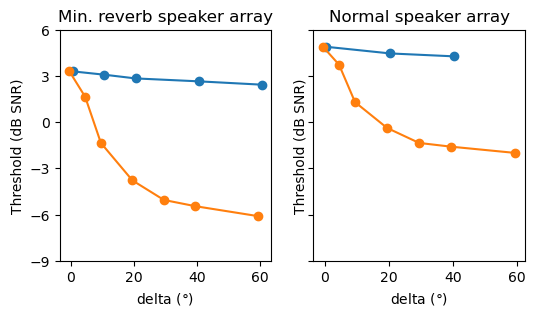

In [40]:


panel_aspect = 3
fig, axs = plt.subplots(1, 2, figsize=(2*panel_aspect, panel_aspect), sharey=True)
to_plot = model_thresh_df[model_thresh_df.azim_delta <= 60]
for i, room_str in enumerate(model_thresh_df.room_str.unique()):
    room_str_data = to_plot[to_plot.room_str == room_str]
    elev_data = room_str_data[room_str_data.azim_delta == 0]
    azim_data = room_str_data[room_str_data.elev_delta == 0]
    ax = axs[i]
    ax.errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold',fmt='o-', label='Elevation')
    ax.errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold',fmt='o-', label='Azimuth')
    ax.set_title(room_str)
    ax.set_xlabel('delta ($\degree$)')
    ax.set_ylabel('Threshold (dB SNR)')
    ax.set_yticks(np.arange(-9, 7,3))

### Plot

<Figure size 640x480 with 0 Axes>

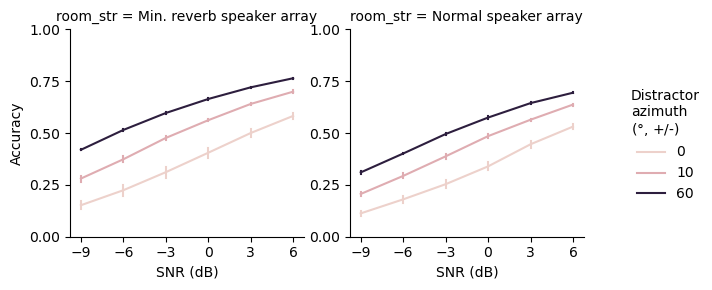

In [33]:


## First, get grand average. Then bootstrap for error 
# sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = grouped_model_results[
                    (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                        & (grouped_model_results.distractor_elev_delta.eq(0 ))
                         & (grouped_model_results.distractor_azim.abs().isin([0,10, 60])) 
                        #   & (grouped_model_results.model.isin(['Early-only', '50Hz Cutoff model', 'Feature-gain model v09',
                        #         'Late-only','Baseline CNN v09',]))
                          ].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



azim_thresholds = []

# col_order = [f'Humans (N={N})', 'Feature-gain model v09', 'Baseline CNN v09', 'Early-only', 'Late-only', '50Hz Cutoff model', 'Dual task model ']
plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='room_str', 
                # row='target_elev', 

                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 


# sns.set_style('white')
# fig, axs = plt.subplots(1,2, figsize=(9, 4))
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

# axs[0].set_xlabel('Distractor azimuth ($\degree$, +/-)')
# axs[0].set_ylabel("Threshold (dB SNR)")
# axs[0].set_ylim(-15,5)
# axs[0].set_xticks(np.arange(0, 31, 10))





# plot azim thresholds





<Figure size 640x480 with 0 Axes>

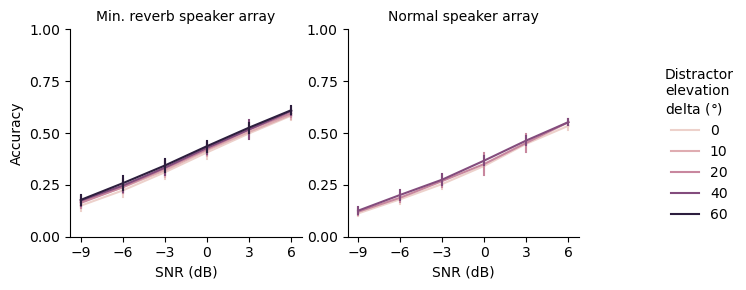

In [43]:
to_plot = grouped_model_results[
                    (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                        # & (grouped_model_results.distractor_elev_delta.isin([0,10,60]))
                        &	(grouped_model_results.distractor_azim == 0) 
                        &	(grouped_model_results.target_elev != 0) 

                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='room_str', #col_order=col_order, col_wrap=3,
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

In [59]:
#### Fit thresholds per model 


merged_results.group.unique()

array(['Early-only', '50Hz Cutoff model', 'Feature-gain model v09',
       'Late-only', nan, 'Baseline CNN v09', 'Dual task model ',
       'Humans (N=33)'], dtype=object)

In [72]:
### Get model thresholds and compare to human thresholds

# get thresholds for each model
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 1_000
for_thresholds = merged_results[merged_results.group != 'Humans (N=33)'].copy()
for_thresholds['azim_delta'] = np.abs(for_thresholds['distractor_azim'] - for_thresholds['target_azim'])
for_thresholds['elev_delta'] = np.abs(for_thresholds['distractor_elev'] - for_thresholds['target_elev'])
thresholds = []
for (model, dist_azim, dist_elev), data in for_thresholds.groupby(['group', 'azim_delta', 'elev_delta']):
    # break
    
    for _ in tqdm(range(n_boots)):
        # sample with replacement
        participant_sample = np.random.choice(data.model.unique(), size=N, replace=True)
        # stack sampled participants - this makes sure data is duplicated if resampled 
        sample_data = pd.concat([data[data.model == model] for model in participant_sample], axis=0, ignore_index=True).reset_index()
        # average participants per SNR 
        sample_data = sample_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()
        # fit to participant average
        try:
            thresh, poly= util_analysis.estimate_threshold_poly(sample_data.snr.values, sample_data.correct_mean.values, degree=2)
        except Exception as e:
            # print(e)
            # print(f"Threshold estimation failed for {model}, {dist_azim}, {dist_elev}")
            thresh = np.nan
        thresholds.append({
                    'model':model, 
                    'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

model_thresh_df = pd.DataFrame(thresholds)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [77]:
model_thresh_summary = model_thresh_df.groupby(['model', 'azim_delta', 'elev_delta']).agg({'threshold':['mean', 'std']}).reset_index()
model_thresh_summary.columns = ['_'.join(col).strip() for col in model_thresh_summary.columns.values]
model_thresh_summary.columns = [col[:-1] if col[-1] == '_' else col for col in model_thresh_summary.columns.values]

In [79]:
model_thresh_summary = model_thresh_summary[model_thresh_summary.azim_delta <= 60]

In [95]:
elev_data

,model,azim_delta,elev_delta,threshold_mean,threshold_std
0,50Hz Cutoff model,0,0.0,4.729730,0.0
1,50Hz Cutoff model,0,10.0,4.486486,0.0
2,50Hz Cutoff model,0,60.0,3.945946,0.0


In [94]:
azim_data

,model,azim_delta,elev_delta,threshold_mean,threshold_std
0,50Hz Cutoff model,0,0.0,4.729730,0.0
4,50Hz Cutoff model,10,0.0,3.297297,0.0
8,50Hz Cutoff model,60,0.0,-1.432432,0.0


In [1]:
model_thresh_summary

NameError: name 'model_thresh_summary' is not defined

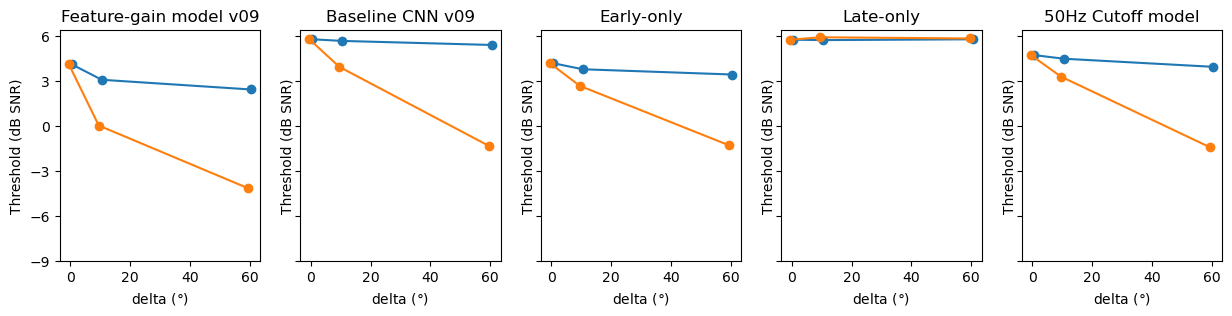

In [101]:
to_plot = model_thresh_summary[(model_thresh_summary.azim_delta.isin([0,10,60])) & (model_thresh_summary.elev_delta.isin([0, 10, 60]))].copy()

model_order = [f'Feature-gain model v09', 'Baseline CNN v09', 'Early-only', 'Late-only', '50Hz Cutoff model']
n_models = len(model_order)

panel_aspect = 3
fig, axs = plt.subplots(1, n_models, figsize=(n_models*panel_aspect, panel_aspect), sharey=True)

for i, model in enumerate(model_order):
    model_data = to_plot[to_plot.model == model]
    elev_data = model_data[model_data.azim_delta == 0]
    azim_data = model_data[model_data.elev_delta == 0]
    ax = axs[i]
    ax.errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold_mean', yerr='threshold_std', fmt='o-', label='Elevation')
    ax.errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold_mean', yerr='threshold_std', fmt='o-', label='Azimuth')
    ax.set_title(model)
    ax.set_xlabel('delta ($\degree$)')
    ax.set_ylabel('Threshold (dB SNR)')
    ax.set_yticks(np.arange(-9, 7,3))